# 03. Dictionary Learning & Sparse Reconstruction - NinaPro DB1 (Subject 1)
**Objective:** Train an overcomplete dictionary on the clean training set to extract biological motor unit action potentials (atoms), and project test signals into this sparse feature space using Orthogonal Matching Pursuit (OMP).

In [3]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from src.dictionary import EMGDictionaryLearner, OMPFeatureExtractor
from src.reconstruction import reconstruct_signal, calculate_reconstruction_metrics
from src.config import PREPROCESSED_DIR

plt.style.use('seaborn-v0_8-whitegrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load Preprocessed HDF5 Data
We load the balanced windows generated in step 02.

In [4]:
file_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1.h5")
with h5py.File(file_path, 'r') as f:
    X_bal = np.array(f['X'])
    y_bal = np.array(f['y'])
    reps_bal = np.array(f['reps'])

print(f"Loaded Balanced X: {X_bal.shape}")
print(f"Loaded Balanced y: {y_bal.shape}")
print(f"Loaded Balanced reps: {reps_bal.shape}")

Loaded Balanced X: (18630, 20, 10)
Loaded Balanced y: (18630,)
Loaded Balanced reps: (18630,)


### 2. Repetition-Based Train/Test Split
In sEMG classification, we MUST split by repetition to avoid temporal data leakage. 

DB1 contains 10 repetitions per gesture. We will use Repetitions 1-7 for Training, and 8-10 for Testing.

In [5]:
train_reps = [1, 2, 3, 4, 5, 6, 7]
test_reps = [8, 9, 10]

train_idx = np.where(np.isin(reps_bal, train_reps))[0]
test_idx = np.where(np.isin(reps_bal, test_reps))[0]

X_train, y_train = X_bal[train_idx], y_bal[train_idx]
X_test, y_test = X_bal[test_idx], y_bal[test_idx]

print(f"Training Set: {X_train.shape[0]} windows")
print(f"Testing Set: {X_test.shape[0]} windows")

# Flatten the spatial-temporal windows (Windows, Samples * Channels)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened Training Shape: {X_train_flat.shape}")

Training Set: 12664 windows
Testing Set: 5444 windows
Flattened Training Shape: (12664, 200)


### 3. Train the Sparse Dictionary
We learn the dictionary strictly from the training set.

In [6]:
learner = EMGDictionaryLearner(n_atoms=256, n_nonzero_coefs=15, batch_size=1024)
learner.fit(X_train_flat)
learner.save_dictionary("emg_dict_DB1_S1.npz")

Training Dictionary with 256 atoms on data shape (12664, 200)...
Dictionary learning complete.
Dictionary saved to /workspaces/TCC/models/emg_dict_DB1_S1.npz


### 4. Signal Reconstruction via OMP
We project an unseen test window onto the learned dictionary and reconstruct it to evaluate physical fidelity.

In [7]:
extractor = OMPFeatureExtractor(learner.dictionary_, n_nonzero_coefs=15)

# Target the first active gesture window in the test set
active_test_idx = np.where(y_test > 0)[0][0]
test_signal = X_test_flat[active_test_idx]
sparse_code = extractor.transform(test_signal.reshape(1, -1))[0]

print(f"Extracted Sparse Code Shape: {sparse_code.shape}")
print(f"Number of Non-Zero Coefficients: {np.count_nonzero(sparse_code)}")

# Reconstruct
reconstructed_signal = reconstruct_signal(sparse_code, learner.dictionary_)
rmse, prd = calculate_reconstruction_metrics(test_signal, reconstructed_signal)

print(f"Reconstruction RMSE: {rmse:.4f}")
print(f"Reconstruction PRD: {prd:.2f}%")

Extracted Sparse Code Shape: (256,)
Number of Non-Zero Coefficients: 15
Reconstruction RMSE: 0.2931
Reconstruction PRD: 66.13%


### 5. Visualizing Reconstruction Quality
Plotting the original test signal vs the OMP reconstructed signal.

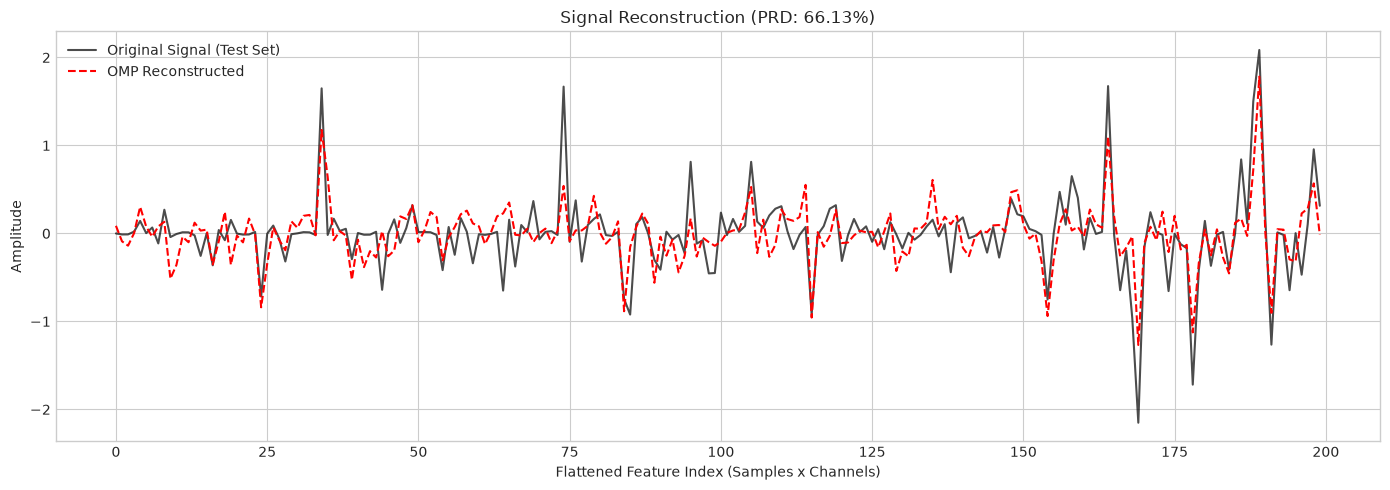

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(test_signal, label="Original Signal (Test Set)", color="black", alpha=0.7)
plt.plot(reconstructed_signal, label="OMP Reconstructed", color="red", linestyle="--")
plt.title(f"Signal Reconstruction (PRD: {prd:.2f}%)")
plt.xlabel("Flattened Feature Index (Samples x Channels)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

### 6. Visualizing the Learned Atoms
Inspecting a subset of the learned dictionary atoms (extracted motor unit templates).

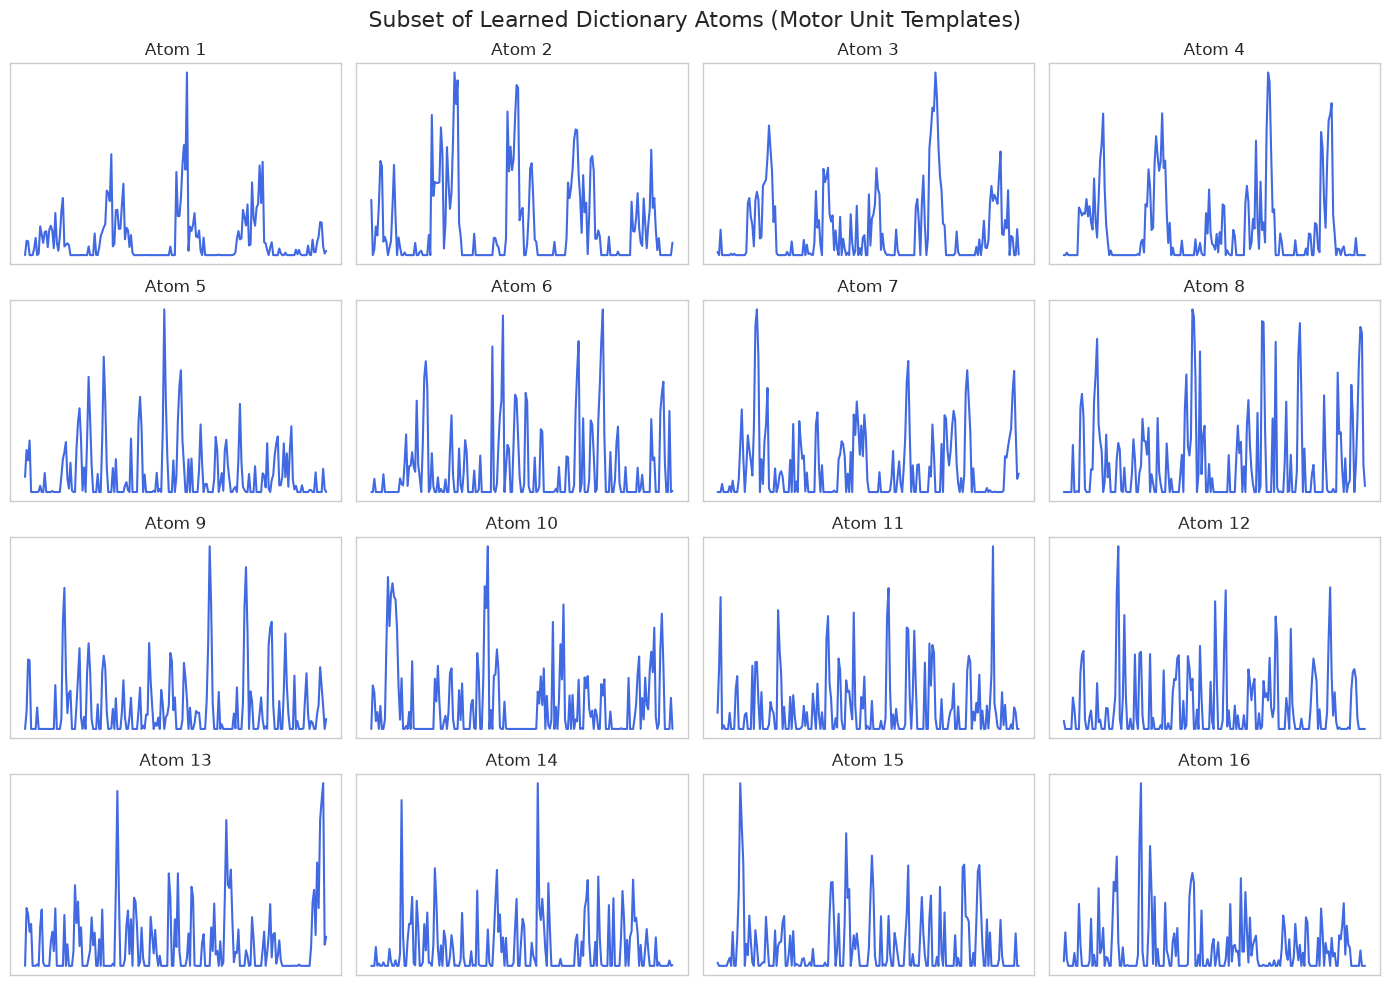

In [9]:
n_atoms_to_plot = 16
fig, axes = plt.subplots(4, 4, figsize=(14, 10))

for i, ax in enumerate(axes.flatten()):
    if i < n_atoms_to_plot:
        ax.plot(learner.dictionary_[i], color="royalblue")
        ax.set_title(f"Atom {i+1}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Subset of Learned Dictionary Atoms (Motor Unit Templates)", fontsize=16)
plt.tight_layout()
plt.show()